<a href="https://colab.research.google.com/github/Baygsemaj/Business-data-project/blob/main/Business_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Business Sales & Profit Analysis

## Objective
To analyze sales and profitability across categories, regions, and discount strategies to identify key business insights.

## 📂 Data Loading
In this section, we import and inspect the dataset.

In [9]:
from google.colab import files
uploaded=files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


In [10]:
import pandas as pd

df=pd.read_csv("SampleSuperstore.csv")
df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 🔍 Data Understanding
We explore the dataset structure, data types, and basic statistics.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [12]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


## 📊 Exploratory Data Analysis
This section analyzes sales, profit, and patterns across different dimensions.

In [17]:
df[['Sales','Profit']].sum()

,0
Sales,2.297201e+06
Profit,2.863970e+05


In [18]:
df['Sales'].mean()

np.float64(229.85800083049833)

In [19]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [20]:
df.groupby('Category')['Profit'].sum().sort_values()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


## 📈 Visualizations & Insights
We use charts to uncover patterns and explain business performance.

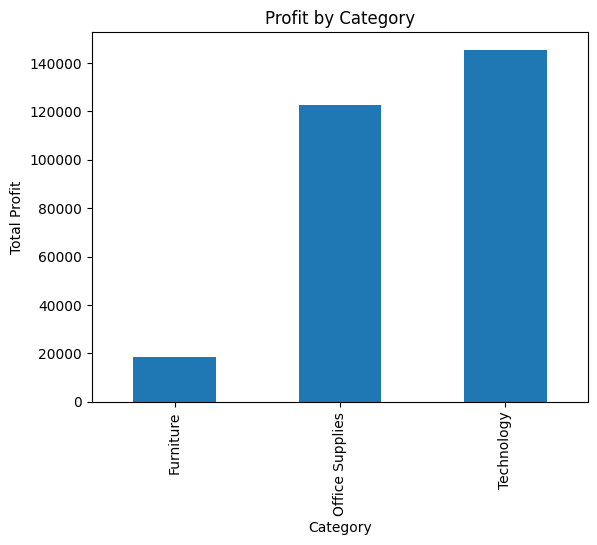

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group data
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

# Plot
plt.figure()
category_profit.plot(kind='bar')

# Labels
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

The Technology category generates the highest profit, while Furniture shows significantly lower profitability, suggesting potential inefficiencies or high costs in that segment

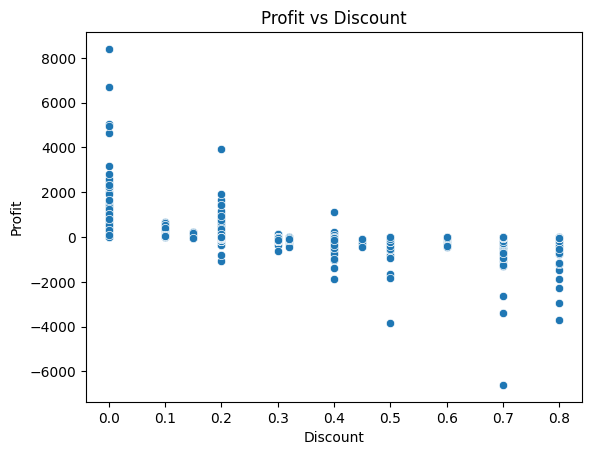

In [22]:
plt.figure()
sns.scatterplot(data=df, x='Discount', y='Profit')

plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Higher discounts are frequently associated with negative profit, indicating that aggressive discounting may be harming overall profitability

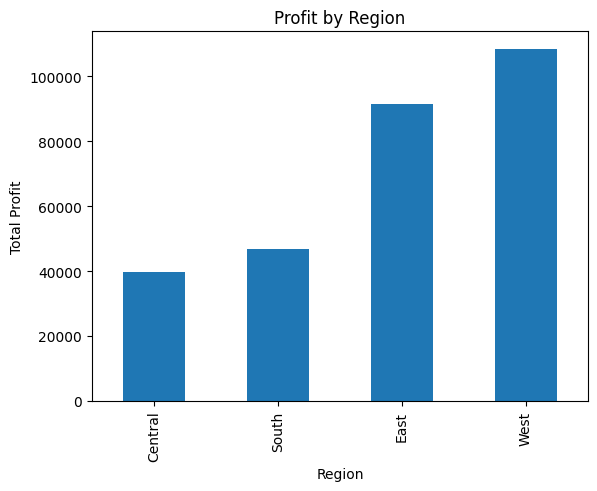

In [23]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure()
region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

### 📊 Insight: Profit by Region

The West region generates the highest profit, while the Central region underperforms. This suggests that business strategies in lower-performing regions may need to be reassessed to improve profitability.

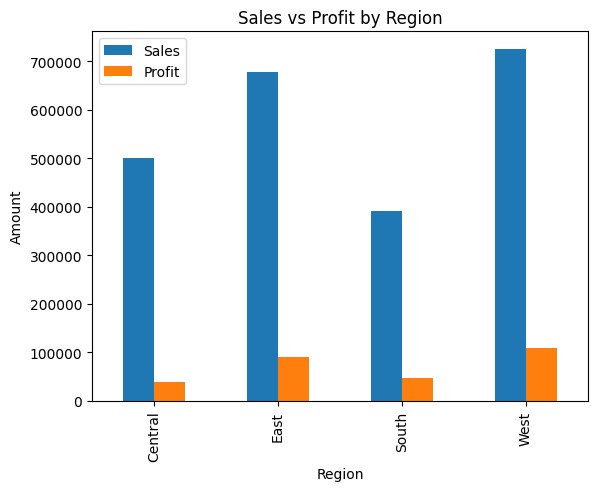

In [24]:
region_data = df.groupby('Region')[['Sales', 'Profit']].sum()

region_data.plot(kind='bar')

plt.title("Sales vs Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")

plt.show()

### 📊 Insight: Sales vs Profit by Region

While some regions generate high sales, their profit does not scale proportionally. This indicates potential inefficiencies such as high costs or excessive discounting in those regions.

## 🧠 Conclusion

- High discounts negatively impact profit  
- Some regions generate strong sales but weaker profit  
- Certain product categories underperform in profitability  

### 💡 Recommendations
- Reduce excessive discounting  
- Focus on high-profit categories  
- Improve strategy in low-performing regions  